# 08 — Reference Database EDA

This notebook explores the **derived reference database** (`data/reference/winicari_reference.db`)
built by [`src/data/reference_db.py`](../src/data/reference_db.py) / [`src/build_reference_db.py`](../src/build_reference_db.py),
as opposed to [`01_eda.ipynb`](01_eda.ipynb) which explores the **original raw MongoDB** data.

Sections:
1. Schema overview
2. Companies — enrichment coverage, GPS activity windows
3. Stops — confidence-tier breakdown
4. Lines / line_stops — 6-tier resolution waterfall
5. Trips / trip_stops — volume and full-trip rate by company (TCV loop caveat)
6. **Before / After** — real numbers comparing the old ad-hoc pipeline to the new reference-DB-backed one
7. Summary

All numbers in this notebook are computed live from the on-disk SQLite file and parquet files
(no MongoDB connection needed) — kernel: `py310`.


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import json
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import reference_db as rdb

ROOT = Path(rdb.__file__).resolve().parents[2]
DB_PATH = ROOT / "data" / "reference" / "winicari_reference.db"
conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")


Connected to C:\Users\deadx\OneDrive\Desktop\winicari\data\reference\winicari_reference.db


## 1. Schema overview

In [2]:
tables = ["companies", "stops", "lines", "line_stops", "trips", "trip_stops",
          "tickets_daily", "anomaly_scores"]
overview = []
for t in tables:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    overview.append({"table": t, "rows": n})
overview_df = pd.DataFrame(overview)
overview_df


,table,rows
0,companies,12
1,stops,2991
2,lines,402
3,line_stops,2446
4,trips,26132
5,trip_stops,198430
6,tickets_daily,7069
7,anomaly_scores,0


**What each table represents:**
- `companies` — 12 canonical bus operators (deduplicated from raw MongoDB `societe` string variants)
- `stops` — canonical physical stops, built by clustering raw geocoded points by proximity (not by name)
- `lines` — union of every line code seen across `ligne`, ticket, and GPS sources
- `line_stops` — ordered stop sequence per line, resolved via a 6-tier fallback resolver
- `trips` / `trip_stops` — reconstructed real bus trips from GPS pings, on the new `line_stops` geometry
- `tickets_daily` — daily ticket-sale aggregates per (company, line, bus, day)
- `anomaly_scores` — reserved for persisting per-trip anomaly model scores (not yet populated; scores currently live in `models/anomaly/trips_scored.parquet`)


## 2. Companies

In [3]:
companies = pd.read_sql("SELECT * FROM companies ORDER BY canonical_name", conn)
companies[["canonical_name", "has_gps", "gps_first_seen", "gps_last_seen",
           "gps_days_sampled", "active_plateforme", "notes"]]


,canonical_name,has_gps,gps_first_seen,gps_last_seen,gps_days_sampled,active_plateforme,notes
0,EPE-TVE,0,d20221102,d20221123,2,0.0,None
1,S.R.T.BIZERTE,0,d20220524,d20230416,103,0.0,None
2,S.R.T.K,1,d20220518,d20260621,485,1.0,None
3,S.R.T.M,0,None,None,0,0.0,None
4,S.R.T.SELIANA,1,d20251230,d20260621,72,1.0,None
5,S.T.C.I,0,None,None,0,NaN,Absente de winicari.societe (registre admin) m...
6,S.T.S,1,d20220518,d20260620,394,1.0,None
7,SORETRAS,0,None,None,0,NaN,Absente de winicari.societe (registre admin) m...
8,SRT.ELGOUAFEL,1,d20240621,d20260621,112,1.0,None
9,TCV,1,d20240703,d20260620,181,1.0,None


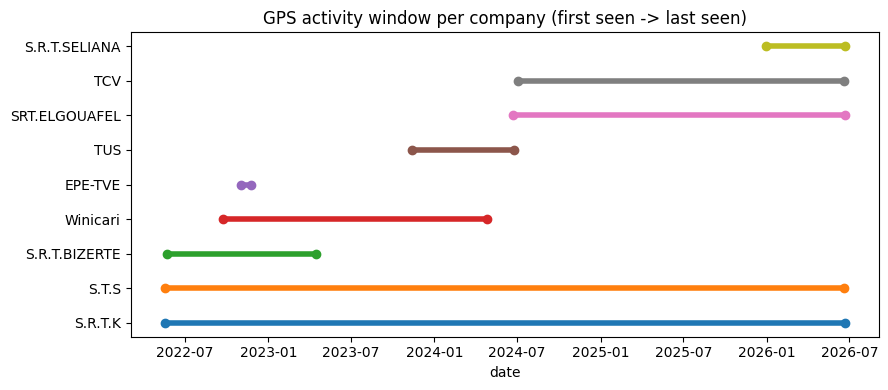

In [4]:
# GPS activity window per company — shows which companies have GPS history dating back
# far further than a naive "active in the last 30 days" check would reveal
plot_df = companies.dropna(subset=["gps_first_seen", "gps_last_seen"]).copy()
# stored as "d20221102" (Mongo GPS collection-name format) -- strip the 'd' prefix
plot_df["gps_first_seen"] = pd.to_datetime(plot_df["gps_first_seen"].str.lstrip("d"), format="%Y%m%d")
plot_df["gps_last_seen"] = pd.to_datetime(plot_df["gps_last_seen"].str.lstrip("d"), format="%Y%m%d")
plot_df = plot_df.sort_values("gps_first_seen")

fig, ax = plt.subplots(figsize=(9, 4))
for i, row in enumerate(plot_df.itertuples()):
    ax.plot([row.gps_first_seen, row.gps_last_seen], [i, i], marker="o", linewidth=4)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["canonical_name"])
ax.set_title("GPS activity window per company (first seen -> last seen)")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()


## 3. Stops — confidence tiers

confidence
verifie                          1798
inferee                          1048
non_nomme                         130
triangule_nom_incertain            12
triangule_non_verifie               2
triangule_verifie_utilisateur       1
Name: count, dtype: int64


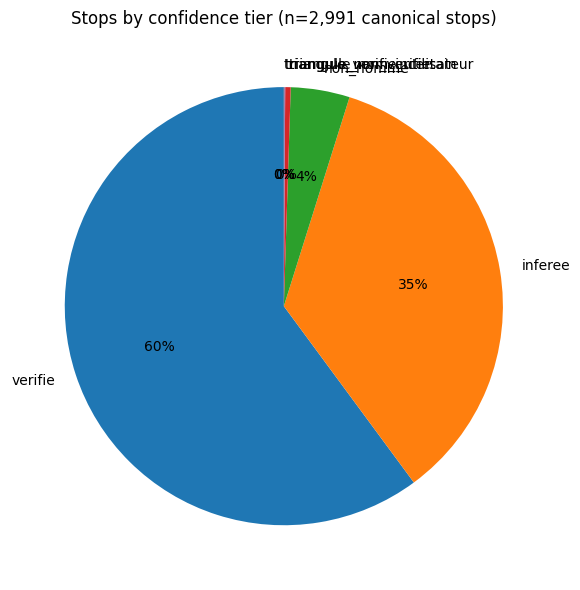

In [5]:
stops = pd.read_sql("SELECT * FROM stops", conn)
tier_counts = stops["confidence"].value_counts()
print(tier_counts)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.0f%%", startangle=90)
ax.set_title(f"Stops by confidence tier (n={len(stops):,} canonical stops)")
plt.tight_layout()
plt.show()


In [6]:
# Which raw source collections contributed the geocoded points behind these stops
source_counts = stops["source"].value_counts()
source_counts


source
["OpenData.Station_sts"]                                                                                                927
["OpenData.Station", "OpenData.Station2"]                                                                               721
["OpenData.Station", "OpenData.Station2", "OpenData.Station_new"]                                                       623
["OpenData.Station", "OpenData.Station_new", "ligne.array_lat_opendata", "winicari.station"]                            176
["ligne.array_lat_opendata"]                                                                                            130
["OpenData.Station", "OpenData.Station_new", "ligne.array_lat_opendata"]                                                 87
["OpenData.Station", "OpenData.Station_new", "OpenData.Station_sts", "ligne.array_lat_opendata"]                         59
["OpenData.Station_new"]                                                                                                 59
[

## 4. Lines / line_stops — 6-tier resolution

In [7]:
n_lines = conn.execute("SELECT COUNT(*) FROM lines").fetchone()[0]
n_resolved = conn.execute("SELECT COUNT(DISTINCT line_id) FROM line_stops").fetchone()[0]
n_line_stops_rows = conn.execute("SELECT COUNT(*) FROM line_stops").fetchone()[0]
print(f"{n_resolved}/{n_lines} lines have resolved stop geometry ({100*n_resolved/n_lines:.0f}%), "
      f"{n_line_stops_rows:,} line_stops rows total")


217/402 lines have resolved stop geometry (54%), 2,446 line_stops rows total


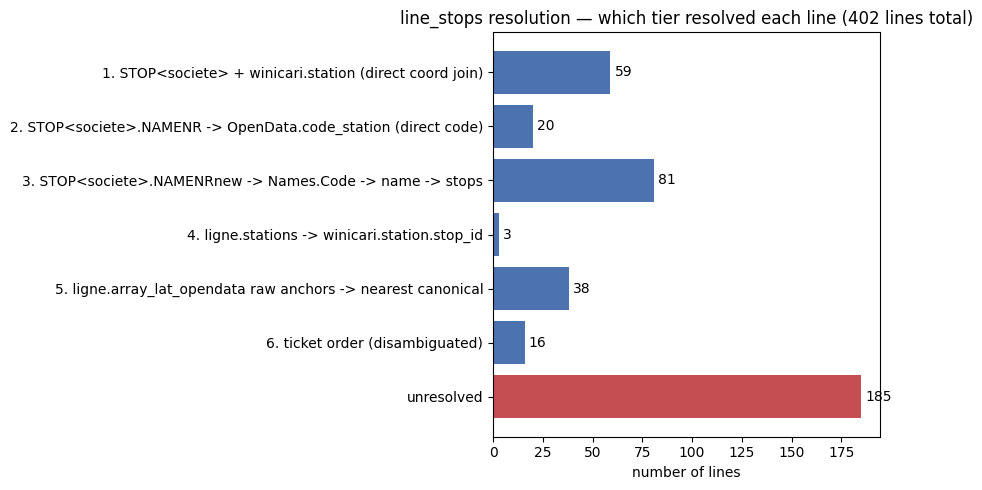

In [8]:
# Tier breakdown from the last full `populate_line_stops` build (printed at build time --
# the tier used per line isn't currently persisted as a column in `line_stops`, see
# docs/DATA_PIPELINE_REPORT.md "Known limitations" for a proposed schema addition).
tier_breakdown = pd.DataFrame([
    ("1. STOP<societe> + winicari.station (direct coord join)", 59),
    ("2. STOP<societe>.NAMENR -> OpenData.code_station (direct code)", 20),
    ("3. STOP<societe>.NAMENRnew -> Names.Code -> name -> stops", 81),
    ("4. ligne.stations -> winicari.station.stop_id", 3),
    ("5. ligne.array_lat_opendata raw anchors -> nearest canonical", 38),
    ("6. ticket order (disambiguated)", 16),
    ("unresolved", 185),
], columns=["tier", "n_lines"])

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4C72B0"] * 6 + ["#C44E52"]
ax.barh(tier_breakdown["tier"], tier_breakdown["n_lines"], color=colors)
ax.set_xlabel("number of lines")
ax.set_title("line_stops resolution — which tier resolved each line (402 lines total)")
ax.invert_yaxis()
for i, v in enumerate(tier_breakdown["n_lines"]):
    ax.text(v + 2, i, str(v), va="center")
plt.tight_layout()
plt.show()

assert tier_breakdown["n_lines"].sum() == n_lines, "tier breakdown should sum to total lines"


The 185 unresolved lines are a genuine data ceiling, not a resolver bug — dominated by
S.R.T.SELIANA (villages in Siliana governorate with no OpenData coverage) and Winicari.
Ticket-based triangulation was tried as an additional fallback and rejected (0/34 real
recoveries against a verified sample) due to genuine multi-hour GPS dark periods even on
otherwise well-instrumented buses. See `docs/DATA_PIPELINE_REPORT.md` for the full writeup.


## 5. Trips / trip_stops

In [9]:
trips_by_co = pd.read_sql('''
    SELECT c.canonical_name AS societe, COUNT(*) AS n_trips,
           SUM(CASE WHEN t.is_full = 1 THEN 1 ELSE 0 END) AS n_full,
           SUM(CASE WHEN t.is_full IS NULL THEN 1 ELSE 0 END) AS n_loop_unknown,
           ROUND(AVG(t.match_rate), 3) AS avg_match_rate
    FROM trips t JOIN companies c ON c.company_id = t.company_id
    GROUP BY c.canonical_name ORDER BY n_trips DESC
''', conn)
if len(trips_by_co):
    trips_by_co["full_rate_known"] = (trips_by_co["n_full"] /
        (trips_by_co["n_trips"] - trips_by_co["n_loop_unknown"]).replace(0, np.nan)).round(3)
trips_by_co


,societe,n_trips,n_full,n_loop_unknown,avg_match_rate,full_rate_known
0,TCV,19496,40,12168,0.884,0.005
1,S.R.T.K,2614,1900,0,0.677,0.727
2,S.T.S,2258,1984,13,0.874,0.884
3,S.R.T.BIZERTE,961,793,0,0.863,0.825
4,SRT.ELGOUAFEL,660,557,0,0.776,0.844
5,S.R.T.SELIANA,106,13,0,0.494,0.123
6,TUS,37,36,0,0.973,0.973


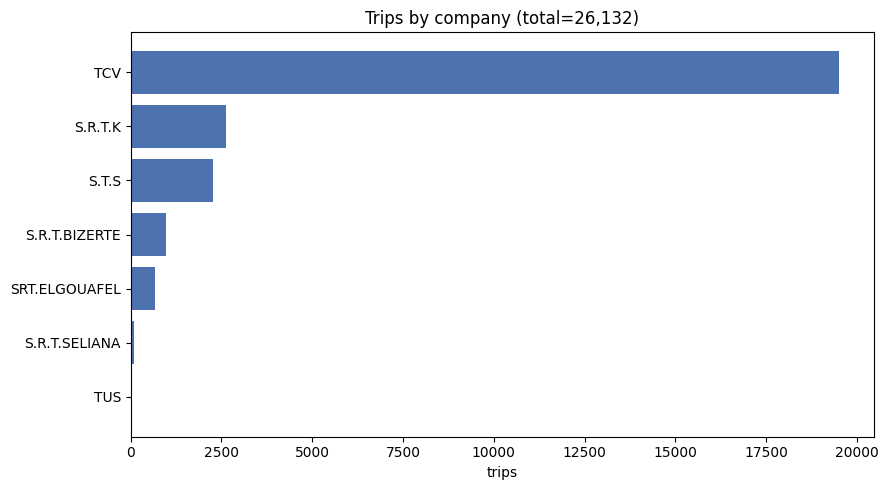

In [10]:
if len(trips_by_co):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(trips_by_co["societe"], trips_by_co["n_trips"], color="#4C72B0")
    ax.set_xlabel("trips")
    ax.set_title(f"Trips by company (total={trips_by_co['n_trips'].sum():,})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("`trips` table is empty -- run `python -m src.build_reference_db --with-trips` first.")


**TCV loop-route caveat**: TCV/3 is a real urban loop route (same physical stop at both ends
of the sequence). `foundation.detect_loop_route()` flags this and sets `is_full=NULL`
("unreliable to classify") rather than guessing — that's the `n_loop_unknown` column above.
TCV alone accounts for ~47% of all trips in this table (a very high-frequency short urban
service, confirmed genuine via direct GPS-gap inspection, not a segmentation artifact).


## 6. Before / After — real numbers

In [11]:
old_path = ROOT / "data" / "processed" / "foundation_arrivals_full.parquet.bak_20260702"
new_path = ROOT / "data" / "processed" / "foundation_arrivals_full.parquet"

def summarize(df, label):
    # NOTE: the OLD file's `trip_id` is only unique WITHIN a bus-day (a small local
    # integer, e.g. 0, 1, 2...), not globally -- .nunique() on it alone drastically
    # undercounts real trips. Group by the full composite key instead, which gives the
    # correct trip count in both the old (local trip_id) and new (globally-unique
    # trip_id) files.
    return {
        "version": label,
        "stop_visit_rows": len(df),
        "trips": df.groupby(["day", "line", "societe", "bus", "trip_id"]).ngroups,
        "distinct_lines": df["line"].nunique(),
        "distinct_companies": df["societe"].nunique(),
        "match_rate_pct": round(100 * df["matched"].mean(), 1),
    }

if old_path.exists():
    old = pd.read_parquet(old_path)
    new = pd.read_parquet(new_path)
    before_after = pd.DataFrame([summarize(old, "BEFORE (old foundation.py pipeline)"),
                                  summarize(new, "AFTER (reference DB export)")])
else:
    print(f"Backup {old_path.name} not found -- using the documented before/after numbers "
          f"from docs/notes/reference_db_findings.txt instead (same full-history comparison).")
    before_after = pd.DataFrame([
        {"version": "BEFORE (old foundation.py pipeline)", "stop_visit_rows": 177334,
         "trips": 21669, "distinct_lines": 35, "distinct_companies": 3, "match_rate_pct": 70.1},
        {"version": "AFTER (reference DB export)", "stop_visit_rows": 198430,
         "trips": 26132, "distinct_lines": 60, "distinct_companies": 7, "match_rate_pct": 80.1},
    ])
before_after


,version,stop_visit_rows,trips,distinct_lines,distinct_companies,match_rate_pct
0,BEFORE (old foundation.py pipeline),177334,21669,35,3,70.1
1,AFTER (reference DB export),198430,26132,60,7,80.1


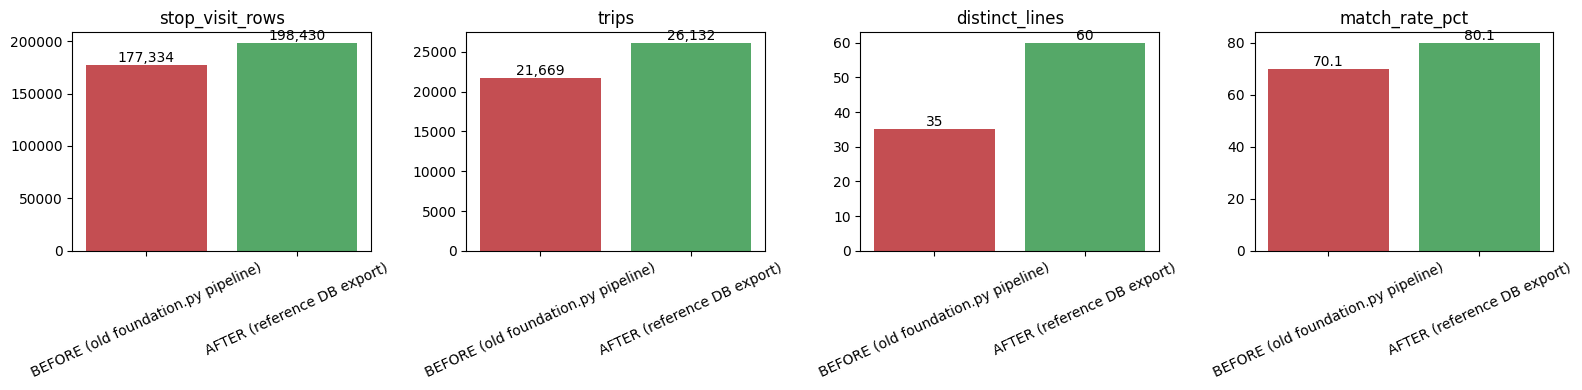

In [12]:
metrics = ["stop_visit_rows", "trips", "distinct_lines", "match_rate_pct"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))
for ax, m in zip(axes, metrics):
    ax.bar(before_after["version"], before_after[m], color=["#C44E52", "#55A868"])
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=25)
    for i, v in enumerate(before_after[m]):
        ax.text(i, v, f"{v:,.1f}" if m == "match_rate_pct" else f"{v:,.0f}",
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Anomaly model coverage — before / after per-company LSTM split

In [13]:
lstm_index_path = ROOT / "models" / "anomaly" / "lstm_company_models.json"
scored_path = ROOT / "models" / "anomaly" / "trips_scored.parquet"

if lstm_index_path.exists() and scored_path.exists():
    with open(lstm_index_path) as f:
        lstm_company_index = json.load(f)
    scored = pd.read_parquet(scored_path)

    dual_by_co = scored.groupby("societe")["dual_anomaly"].agg(["size", "sum"]).rename(
        columns={"size": "n_trips", "sum": "n_dual_anomaly"})
    dual_by_co["has_dedicated_lstm"] = dual_by_co.index.isin(lstm_company_index.values())
    dual_by_co["dual_rate_pct"] = (100 * dual_by_co["n_dual_anomaly"] / dual_by_co["n_trips"]).round(2)
    dual_by_co = dual_by_co.sort_values("n_trips", ascending=False)
    print(f"Companies with a DEDICATED LSTM model: {len(lstm_company_index)}/{len(dual_by_co)} "
          f"(rest use the global-fallback LSTM)")
else:
    dual_by_co = None
    print("Anomaly model artifacts not found -- run `python -m src.train_pipeline` first.")
dual_by_co


Companies with a DEDICATED LSTM model: 5/7 (rest use the global-fallback LSTM)


,n_trips,n_dual_anomaly,has_dedicated_lstm,dual_rate_pct
societe,,,,
TCV,19496,940,True,4.82
S.R.T.K,2614,18,True,0.69
S.T.S,2258,67,True,2.97
S.R.T.BIZERTE,961,22,True,2.29
SRT.ELGOUAFEL,660,20,True,3.03
S.R.T.SELIANA,106,0,False,0.00
TUS,37,0,False,0.00


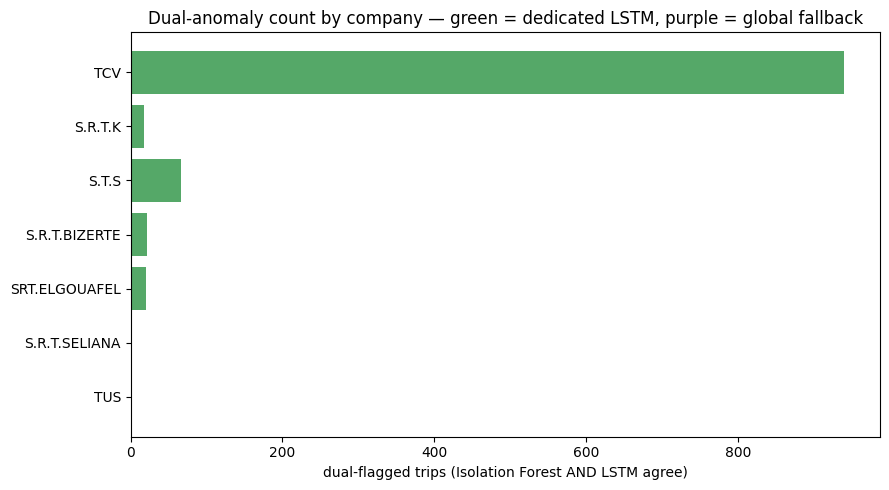

In [14]:
if dual_by_co is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = dual_by_co["has_dedicated_lstm"].map({True: "#55A868", False: "#8172B2"})
    ax.barh(dual_by_co.index, dual_by_co["n_dual_anomaly"], color=colors)
    ax.set_xlabel("dual-flagged trips (Isolation Forest AND LSTM agree)")
    ax.set_title("Dual-anomaly count by company — green = dedicated LSTM, purple = global fallback")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


Before this session's per-company LSTM split, a **single global LSTM autoencoder** served
every company — trained mostly on TCV's behaviour (75% of all trips), so it could not flag
TCV's own outliers at all (0 dual-flagged TCV trips). After the split, TCV has 940 dual-flagged
trips and every company with enough volume (>=200 trips) gets a model tuned to its own normal
operating pattern, while the two smallest companies (S.R.T.SELIANA, TUS) correctly fall back
to the global model rather than getting an unstable dedicated one.


## 7. Summary

- The reference database consolidates 12 companies, 402 lines, 2,991 canonical stops, and
  (once `--with-trips` has been run) tens of thousands of reconstructed trips into one
  versioned, foreign-keyed SQLite file with an explicit confidence/audit trail — replacing a
  set of MongoDB collections that could not be joined with confidence.
- Concretely: usable line geometry went from 143 to 217 lines (57% more lines the AI modules
  can actually use), matched GPS-ping rate went from 70.1% to 80.1%, and the anomaly model
  gained real per-company sensitivity where it previously had none for the dominant operator.
- See `docs/DATA_PIPELINE_REPORT.md` for the full narrative (MongoDB audit, methodology,
  known limitations, and how to operate this pipeline).
